In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

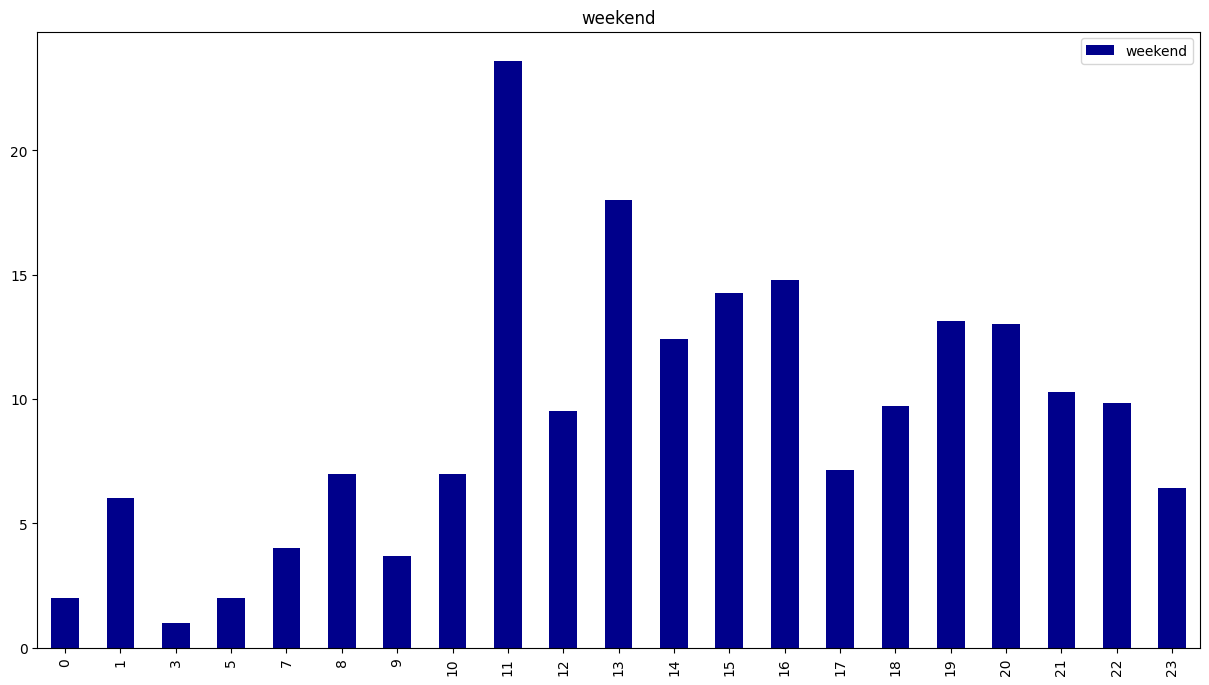

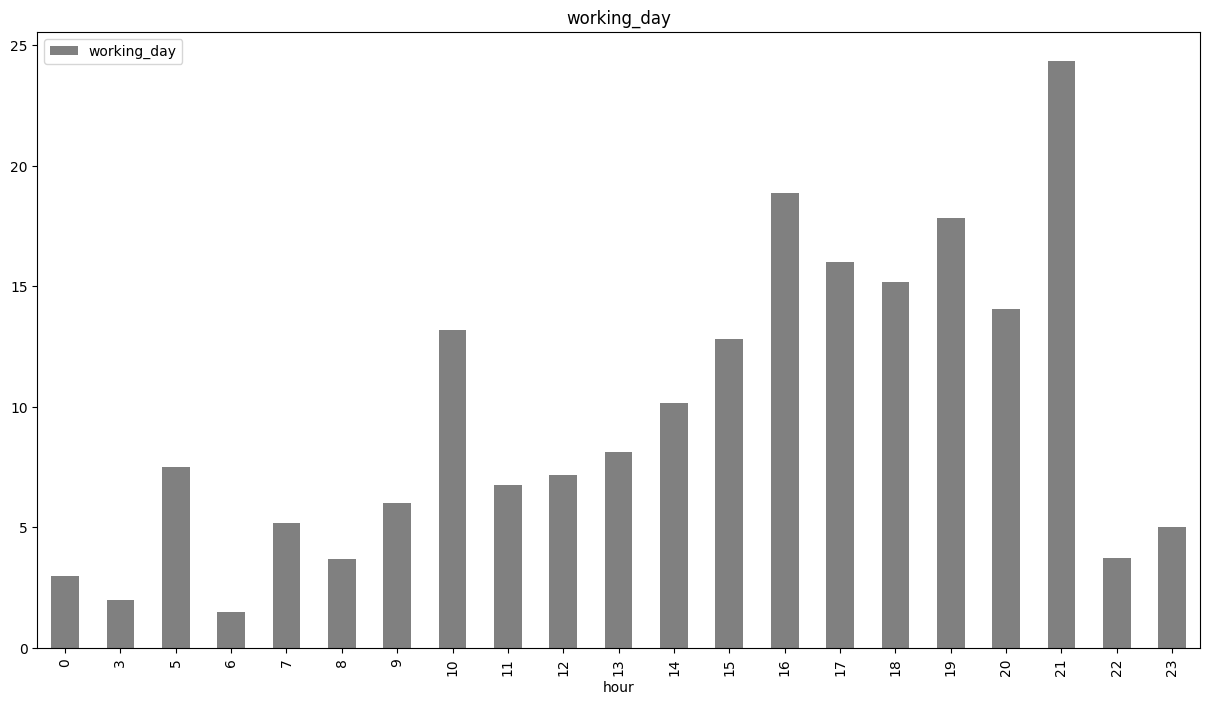

In [3]:
query = '''
SELECT
    timestamp,
    DATE(timestamp) as date,
    TIME(timestamp) as time
FROM
    checker
WHERE
    uid LIKE 'user%'
'''

df = pd.read_sql_query(query, conn)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = pd.to_datetime(df['date'])
df['is_weekend'] = df['date'].dt.weekday >= 5
df['hour'] = df['timestamp'].dt.hour

grouped = df.groupby(['date', 'hour', 'is_weekend']).size().reset_index(name='commits')
average_commits = grouped.groupby(['hour', 'is_weekend'])['commits'].mean().reset_index()
average_commits['day_type'] = average_commits['is_weekend'].apply(lambda x: 'Weekend' if x else 'Weekday')


average_commits_weekday = average_commits[average_commits['day_type'] == 'Weekend']
ax = average_commits_weekday.plot(
    kind='bar',
    x='hour',
    y='commits', 
    figsize=(15, 8),
    title='weekend',
    color = 'darkblue',
    label = 'weekend',
    xlabel=''
)
average_commits_weekday = average_commits[average_commits['day_type'] == 'Weekday']
ax1 = average_commits_weekday.plot(
    kind='bar',
    x='hour',
    y='commits', 
    figsize=(15, 8),
    title='working_day',
    label = 'working_day',
    color = 'grey'
)

conn.close()

## Weekends: 11 
## Weekdays: 21